STAlign test


In [2]:
from wsireg.wsireg2d import WsiReg2D
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import os
import shutil

In [3]:
# files
sample = "lungTMA2"
output_dir = "results/" + sample + "/"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
else:
    shutil.rmtree(output_dir)
    os.mkdir(output_dir)
valid_target_landmarks = "../../../benchmarks/landmarks/LungTMA/" + sample + "/HE_landmarks_corrected.csv"
valid_source_landmarks = "../../../benchmarks/landmarks/LungTMA/" + sample + "/Xenium_landmarks_corrected.csv"
query_img = Image.open('../../../../../analysis/ImageAlignmentBenchmark/data/LungTMA/Xenium/lungTMA_Assay2.tif')
ref_img = Image.open('../../../../../analysis/ImageAlignmentBenchmark/data/LungTMA/HE/lungTMA_2.jpg')


Image size (94206436 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.


In [4]:
# initialize registration graph
reg_graph = WsiReg2D("my_reg_project", output_dir= output_dir)

In [5]:
# add registration images (modalities)
rotated = query_img.rotate(270, expand=True)
query_img_size = rotated.size
rotated.save(output_dir + "input.tiff")
reg_graph.add_modality(
    "modality_fluo",
    output_dir + "input.tiff",
    image_res=1,
    preprocessing={
        "image_type": "BF",
        "as_uint8": True,
        "invert_intensity": True,
    },
)

In [6]:
original_size = ref_img.size
rotated_ref_img = ref_img.resize(query_img_size)
rotated_ref_img.save(output_dir + 'output.tiff')
reg_graph.add_modality(
    "modality_brightfield",
    output_dir + "output.tiff",
    image_res=1,
    preprocessing={
        "image_type": "FL", 
        "as_uint8": True,
        "invert_intensity": False,
    }
)

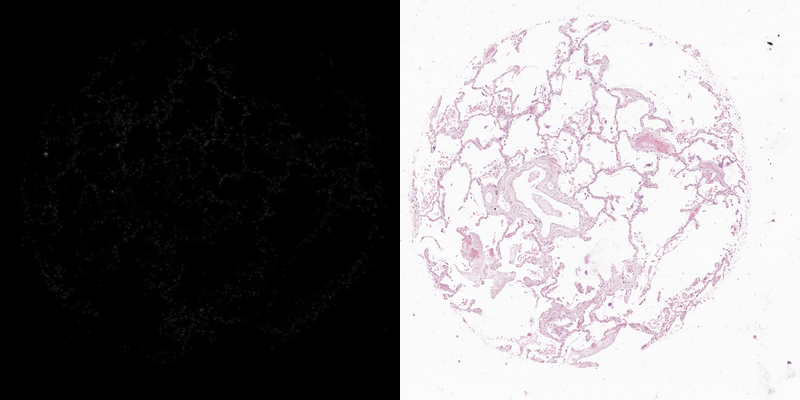

In [7]:
img1 = Image.open(output_dir + 'input.tiff')
img2 = Image.open(output_dir + 'output.tiff')
img1 = img1.resize((400,400), Image.LANCZOS)
img2 = img2.resize((400,400), Image.LANCZOS)
img1 = img1.convert("RGB")
img2 = img2.convert("RGB")
new_img = Image.new("RGB", (800, 400))
new_img.paste(img1, (0, 0))
new_img.paste(img2, (400, 0))
display(new_img)

   Unnamed: 0  KeyPoint            x            y
0           1         1  6472.460825  6542.794917
1           2         2  7798.249816  6369.965401
2           3         3  7928.990615  7534.933139
3           4         4  7447.447879  7675.968202
4           5         5  7226.181802  8410.468598
[[6472.46082528 3163.20508312]
 [7798.24981561 3336.03459896]
 [7928.99061514 2171.0668612 ]
 [7447.44787855 2030.03179811]
 [7226.18180205 1295.53140246]]
   Unnamed: 0  KeyPoint            x            y
0           1         1  4126.939317  4067.929692
1           2         2  4947.781549  3963.452273
2           3         3  5026.602906  4684.123213
3           4         4  4731.285461  4771.920263
4           5         5  4592.902452  5223.092511
[[4126.93931701 2116.07030768]
 [4947.78154855 2220.54772749]
 [5026.60290605 1499.87678749]
 [4731.28546125 1412.07973702]
 [4592.90245193  960.90748855]]


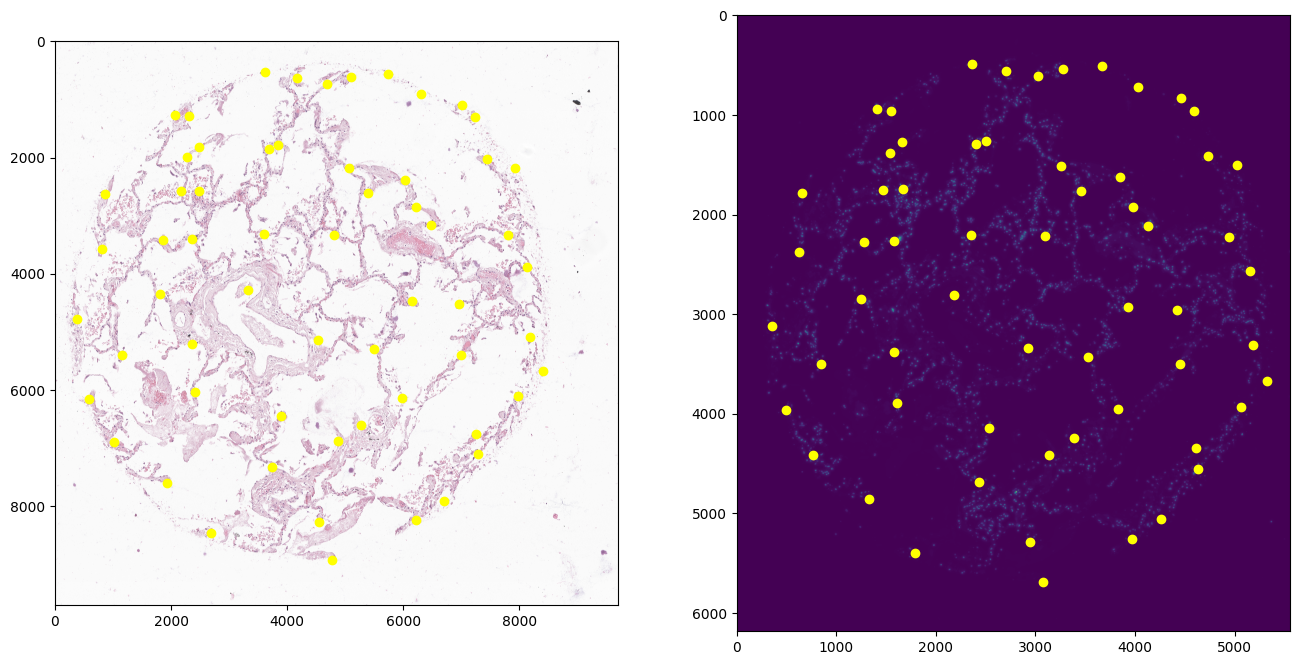

In [8]:
# get landmarks
he_landmarks_df = pd.read_csv(valid_target_landmarks)
print(he_landmarks_df.head())
he_landmarks = np.array(he_landmarks_df[['x', 'y']])
he_landmarks[:,1] =  original_size[1] - he_landmarks[:,1]
print(he_landmarks[:5])
Xenium_landmarks_df = pd.read_csv(valid_source_landmarks)
print(Xenium_landmarks_df.head())
Xenium_landmarks = np.array(Xenium_landmarks_df[['x', 'y']])
Xenium_landmarks[:,1] =  rotated.size[1] - Xenium_landmarks[:,1]
print(Xenium_landmarks[:5])

# visualize landmarks
fig,ax = plt.subplots(1,2)
fig.set_size_inches(16, 8)
img = ref_img
ax[0].scatter(he_landmarks[:,0], he_landmarks[:,1], alpha=1, c="yellow")
ax[0].imshow(img)
img = query_img
rotated = img.rotate(270, expand=True)
ax[1].scatter(Xenium_landmarks[:,0],Xenium_landmarks[:,1],alpha=1, c = "yellow")
ax[1].imshow(rotated)

# add shapes to modality
reg_graph.add_shape_set("modality_fluo", "Xenium_landmarks", {"array": Xenium_landmarks, "shape_type": "Point", "shape_name" : "Xenium_landmarks"}, 1)

In [9]:
reg_graph.add_reg_path(
    "modality_fluo",
    "modality_brightfield",
    thru_modality=None,
    reg_params=["affine"],
)

In [11]:
reg_graph.register_images()
reg_graph.save_transformations()
reg_graph.transform_images(file_writer="ome.tiff")
reg_graph.transform_shapes()

cannot perform maximum intensity project on single channel image
Writing preprocessed image for modality_brightfield
Finished writing preprocessed image for modality_brightfield
using default compression
saving to results/lungTMA2/my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff
transforming : 0
transformed : 0
saving
 writing channel 0 - shape: (6184, 5552)
pyramid index 1 : channel 0 shape: (3092, 2776)
pyramid index 2 : channel 0 shape: (1546, 1388)
pyramid index 3 : channel 0 shape: (773, 694)
preparing transforms for non-registered modality : modality_brightfield 
using default compression
saving to results/lungTMA2/my_reg_project-modality_brightfield_registered.ome.tiff
transforming : 0
transforming : 1
transforming : 2
RGB shape: (6184, 5552, 3)
transforming shape set Xenium_landmarks associated with modality_fluo to modality_brightfield


[PosixPath('results/lungTMA2/my_reg_project-Xenium_landmarks-modality_fluo_to_modality_brightfield-transformed_shapes.geojson')]

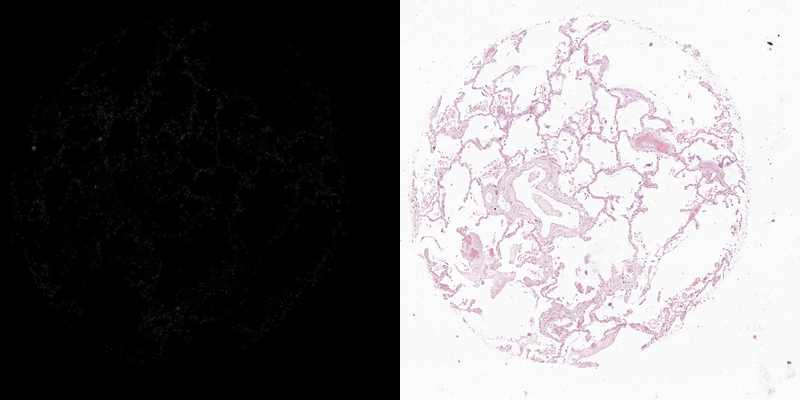

In [12]:
img1 = Image.open(output_dir + 'my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff')
img2 = Image.open(output_dir + 'my_reg_project-modality_brightfield_registered.ome.tiff')
img1 = img1.resize((400,400), Image.LANCZOS)
img2 = img2.resize((400,400), Image.LANCZOS)
img1 = img1.convert("RGB")
img2 = img2.convert("RGB")
new_img = Image.new("RGB", (800, 400))
new_img.paste(img1, (0, 0))
new_img.paste(img2, (400, 0))
display(new_img)

In [13]:
def parse_points_from_geojson(geojson_path):
    with open(geojson_path, 'r') as f:
        data = json.load(f)
    coords = data[0]['geometry']['coordinates']
    coords = np.array(coords)
    return coords

# Find the first .geojson file in the current directory
geojson_file = next((f for f in os.listdir("./" + output_dir) if f.endswith('.geojson')), None)
points = parse_points_from_geojson(output_dir + geojson_file)
print(Xenium_landmarks[:5])
print(points[:5])

# resize back the registered coordinates
points[:, 0] = points[:, 0] * (original_size[0] / query_img_size[0])
points[:, 1] = points[:, 1] * (original_size[1] / query_img_size[1])

# compare registered and unregistered coordinates
print(points[:5])
print(he_landmarks[:5])

[[4126.93931701 2116.07030768]
 [4947.78154855 2220.54772749]
 [5026.60290605 1499.87678749]
 [4731.28546125 1412.07973702]
 [4592.90245193  960.90748855]]
[[3701.57086132 2016.48288167]
 [4461.40827543 2123.81567286]
 [4534.40814991 1381.82624702]
 [4261.0411421  1291.51821166]
 [4132.96438715  827.05269447]]
[[6471.08191282 3164.93901188]
 [7799.42880428 3333.40150724]
 [7927.04710069 2168.82366648]
 [7449.14721276 2027.08210904]
 [7225.24357739 1298.087557  ]]
[[6472.46082528 3163.20508312]
 [7798.24981561 3336.03459896]
 [7928.99061514 2171.0668612 ]
 [7447.44787855 2030.03179811]
 [7226.18180205 1295.53140246]]


In [15]:
# Remove everything under output_dir except .csv and .tiff files
for f in os.listdir(output_dir):
    if not (f.endswith('.csv') or f.endswith('.tiff')):
        path = os.path.join(output_dir, f)
        if os.path.isdir(path):
            shutil.rmtree(path)
        else:
            os.remove(path)

reg_graph = WsiReg2D("my_reg_project", output_dir= output_dir)

reg_graph.add_modality(
    "modality_fluo",
    output_dir + "input.tiff",
    image_res=1,
    preprocessing={
        "image_type": "BF",
        "as_uint8": True,
        "invert_intensity": True,
    },
)
reg_graph.add_modality(
    "modality_brightfield",
    output_dir + "output.tiff",
    image_res=1,
    preprocessing={
        "image_type": "FL", 
        "as_uint8": True,
        "invert_intensity": False,
    }
)
reg_graph.add_shape_set("modality_fluo", "Xenium_landmarks", {"array": Xenium_landmarks, "shape_type": "Point", "shape_name" : "Xenium_landmarks"}, 1)
reg_graph.add_reg_path(
    "modality_fluo",
    "modality_brightfield",
    thru_modality=None,
    reg_params=["rigid", "nl"],
)
reg_graph.register_images()
reg_graph.save_transformations()
reg_graph.transform_images(file_writer="ome.tiff")
reg_graph.transform_shapes()

def parse_points_from_geojson(geojson_path):
    with open(geojson_path, 'r') as f:
        data = json.load(f)
    coords = data[0]['geometry']['coordinates']
    coords = np.array(coords)
    return coords

# Find the first .geojson file in the current directory
geojson_file = next((f for f in os.listdir("./" + output_dir) if f.endswith('.geojson')), None)
nl_points = parse_points_from_geojson(output_dir + geojson_file)
print(Xenium_landmarks[:5])
print(nl_points[:5])

# resize back the registered coordinates
nl_points[:, 0] = nl_points[:, 0] * (original_size[0] / query_img_size[0])
nl_points[:, 1] = nl_points[:, 1] * (original_size[1] / query_img_size[1])


Writing preprocessed image for modality_fluo
Finished writing preprocessed image for modality_fluo
cannot perform maximum intensity project on single channel image
Writing preprocessed image for modality_brightfield
Finished writing preprocessed image for modality_brightfield
using default compression
saving to results/lungTMA2/my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff
transforming : 0
transformed : 0
saving
 writing channel 0 - shape: (6184, 5552)
pyramid index 1 : channel 0 shape: (3092, 2776)
pyramid index 2 : channel 0 shape: (1546, 1388)
pyramid index 3 : channel 0 shape: (773, 694)
preparing transforms for non-registered modality : modality_brightfield 
using default compression
saving to results/lungTMA2/my_reg_project-modality_brightfield_registered.ome.tiff
transforming : 0
transforming : 1
transforming : 2
RGB shape: (6184, 5552, 3)
transform at index 0 is non-linear and the inverse has not been computed
inverting displacement field(s)...
this c

[2.21537999 2.88499329 2.96802476 3.40417425 2.72290131]
[0.87311592 1.19325958 3.2712292  1.32862593 4.54684447]


The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


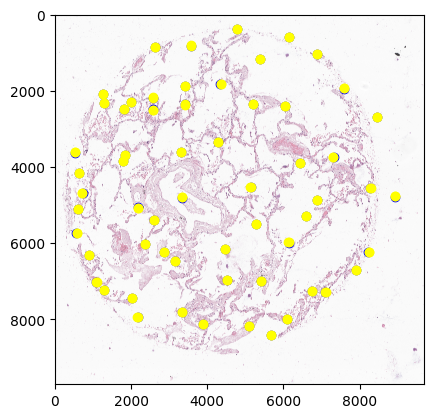

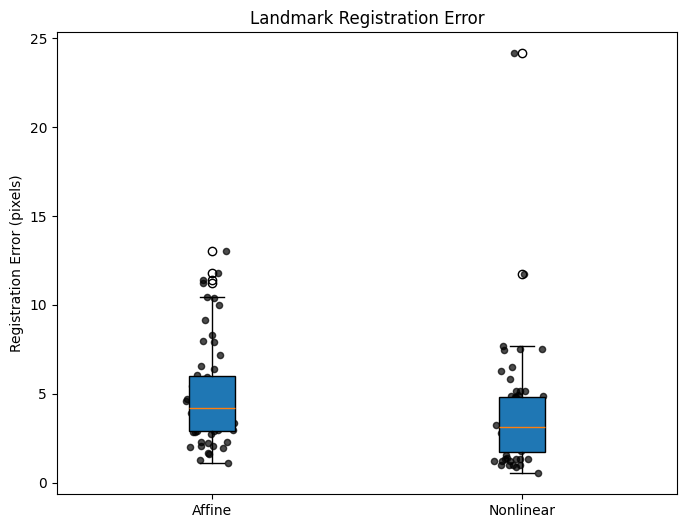

In [16]:
# visualize landmarks
fig,ax = plt.subplots()
img = ref_img
ax.scatter(he_landmarks[:,1], he_landmarks[:,0], alpha=1, c="blue")
ax.scatter(points[:,1], points[:,0], alpha=1, c="yellow")
ax.scatter(nl_points[:,1], nl_points[:,0], alpha=1, c="yellow")
ax.imshow(img)

# get distance between landmark and transformation
diff_affine = np.sqrt(np.power(np.array(points[:,0])-he_landmarks[:,0],2) + np.power(np.array(points[:,1])-he_landmarks[:,1],2))
print(diff_affine[:5])
diff_nl = np.sqrt(np.power(np.array(nl_points[:,0])-he_landmarks[:,0],2) + np.power(np.array(nl_points[:,1])-he_landmarks[:,1],2))
print(diff_nl[:5])

# visualize boxplots with points overlaid
fig2, ax2 = plt.subplots(figsize=(8, 6))
data = [diff_affine, diff_nl]
ax2.boxplot(data, labels=['Affine', 'Nonlinear'], patch_artist=True)
# Overlay the points (jittered for visibility)
for i, diff in enumerate(data, start=1):
    ax2.scatter(np.random.normal(i, 0.04, size=len(diff)), diff, alpha=0.7, color='black', s=20)
ax2.set_ylabel('Registration Error (pixels)')
ax2.set_title('Landmark Registration Error')
plt.show()

# save to data
df = pd.DataFrame({
    'x_landmark': he_landmarks[:,0],
    'y_landmark': he_landmarks[:,1],
    'x_wsireg_affine': points[:,0],
    'y_wsireg_affine': points[:,1],
    'x_wsireg_nl': nl_points[:,0],
    'y_wsireg_nl': nl_points[:,1],
    'diff_affine': diff_affine,
    'diff_nl': diff_nl
})
df.to_csv(output_dir + "all_landmarks.csv")